# Matplotlib 

הספריה **matplotlib** היא דרך פופולרית להצגת גרפים וויזואליזציות בפייתון.היא מאפשרת ליצור תרשימים דו־ממדיים כמו גרפים קוויים, עמודות, פיזור (scatter), תרשימי חום (heatmaps) ועוד. עבור מדענים, היא כלי חיוני להצגת נתונים, תוצאות ניסוי וסימולציות בצורה ברורה. המודול הנפוץ ביותר לשימוש הוא `matplotlib.pyplot`. מודול זה מספק פקודות פשוטות לשרטוט מהיר.

## אנטומיית תרשימים
**מושגים מרכזיים:**
- **Figure** — מכלול התרשים (הדף).
- **Axes** — מערכת צירים אחת (או יותר) בתוך ה־Figure.
- **Axis** — ציר $x$ או $y$ בתוך ה־Axes.

נוסיף כותרות, תוויות, ונוסחאות בעזרת השפה הייעודית $ \LaTeX $ בכותרת/צירים. ראשית, נייבא את הספרייה ונאתחל פרמטרים:

In [2]:
# Core imports used across the notebook
import numpy as np
import matplotlib.pyplot as plt

# Global plotting defaults (optional, feel free to tweak)
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "font.size": 11
})


### שימוש ב־matplotlib

בדוגמה זו נשתמש בספריה ליצירת גרף פשוט:
- נבנה מערך ערכים $x$ בתחום $[0, 2\pi]$. 
- נחשב את $y = \sin(x)$. 
- נשרטט את הגרף של פונקציית הסינוס עם כותרת, שמות לצירים ומפתח (Legend).

```{note}
נלמד את השיטה האובייקטית המסודרת יותר. קיימת גם שיטה עם כתיב מקוצר המיועדת בעיקר לשימוש אינטראקטיבי, אך לא נעסוק בה.
```

### דוגמה: גרף פשוט של הפונקציה $\sin(x)$:

1. **יצירת נתונים**
   - `x = np.linspace(0, 2*np.pi, 200)` יוצר 200 נקודות מ־0 עד $2\pi$ (רדיונים).
   - `y = np.sin(x)` מחשב את ערכי הסינוס עבור כל נקודה.

2. **הגדרת תרשים**
   - `()fig, ax = plt.subplots` יוצר תרשים (`fig`) וציר (`ax`) לעבודה.

3. **ציור הגרף**
   - `ax.plot(x, y, label="sin(x)")` מצייר את $y=\sin(x)$ עם תווית למקרא.

4. **כותרות ותוויות**
   - `ax.set_title(r"$y=\sin(x)$")` מוסיף כותרת עם נוסחת $ \LaTeX $ .
   - `ax.set_xlabel(r"$x$ (rad)")` ו־`ax.set_ylabel(r"$y$")` מוסיף שמות לצירים, כולל יחידות ברדיאנים.

5. **מקרא**
   - `()ax.legend` מציג את המקרא עם התווית שהוגדרה.

6. **פריסה ותצוגה**
   - `()plt.tight_layout` דואג שאין חפיפות בין רכיבי התרשים.
   - `()plt.show` מציג את התרשים על המסך.

בקצרה: הקוד מייצר תרשים של הפונקציה $\sin(x)$ בין $0$ ל־$2\pi$, עם כותרות, יחידות ומקרא.


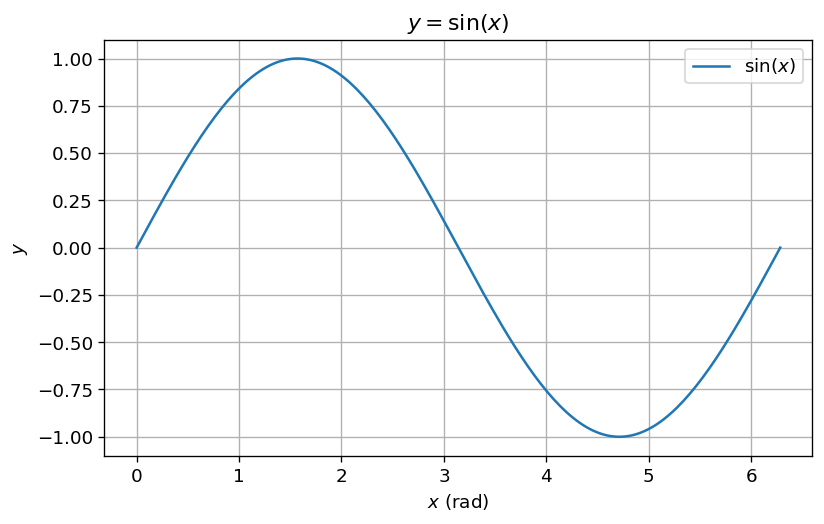

In [3]:
x = np.linspace(0, 2*np.pi, 200)
y = np.sin(x)

fig, ax = plt.subplots()
ax.plot(x, y, label=r"$\sin(x)$")
ax.set_title(r"$y=\sin(x)$")
ax.set_xlabel(r"$x$ (rad)")
ax.set_ylabel(r"$y$")
ax.legend()
plt.tight_layout()
plt.show()

### גודל תרשים, DPI, פריסה ושמירה

בתרשים זה נמחיש כיצד לשלוט בפרמטרים חשובים של אובייקט התרשים Figure: 
- `figsize`: קובע את גודל התרשים באינצ'ים.
- `dpi`: רזולוציית התצוגה (מספר הנקודות/פיקסלים לאינץ').
- `constrained_layout=True`: מאפשר התאמה אוטומטית של פריסת האלמנטים (כותרות, תוויות) כך שלא ייחתכו.
- `(...)fig.savefig`: שמירת התרשים כקובץ (למשל PDF איכותי להדפסה, או PNG למסך).

בדוגמה נצייר את פונקציית הקוסינוס, נוסיף כותרת, שמות לצירים ו־Legend, ונראה כיצד ניתן לשמור את התרשים.

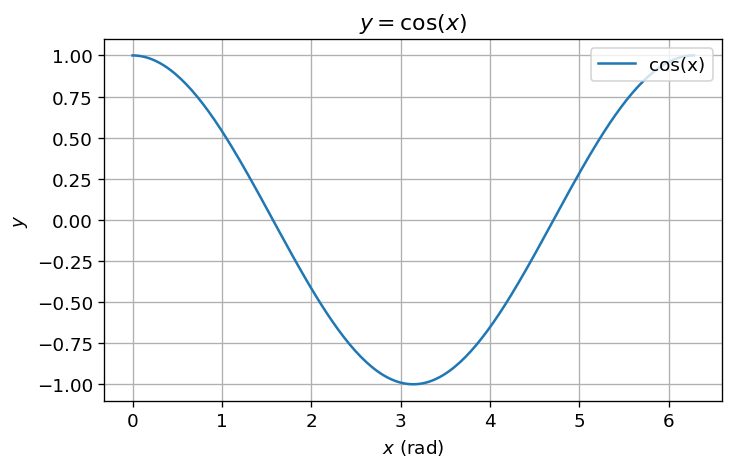

In [4]:
# Figure size, dpi, layout, and saving
fig, ax = plt.subplots(figsize=(6, 3.8), constrained_layout=True)
ax.plot(x, np.cos(x), label=r"$\cos(x)$")
ax.set_title(r"$y=\cos(x)$")
ax.set_xlabel(r"$x$ (rad)")
ax.set_ylabel(r"$y$")
ax.legend(loc="upper right")

# Uncomment to save a publication-quality figure:
# fig.savefig("cosine_plot.pdf")  # vector format (great for print)
plt.show()


### שימוש ב־`axs` לפנלים מרובים

כאשר רוצים לצייר כמה תתי־תרשימים שונים, נוח להשתמש ב־`plt.subplots(rows, cols)` שמחזיר:
- אובייקט figure (`fig`).
- מערך דו־ממדי של צירים (`axs`) בגודל שנבחר.

כך, אפשר לגשת לכל ציר לפי המיקום שלו במערך `axs[row, col]` ולצייר בו גרף עצמאי עם כותרת, תוויות וכו'. בדרך זו ניתן לארגן מספר גרפים מסודרים בטבלה אחת (grid) ולשלוט בכל אחד מהם בנפרד.

לדוגמה בקוד שלמטה: `fig, axs = plt.subplots(2, 3, ...)` יוצר **רשת של 2 שורות ו־3 עמודות** של תרשימים. לאחר מכן ניגשים לכל אחד מהם (`axs[0,0]`, `axs[0,1]`, ... `axs[1,2]`) ומציירים בו סוג גרף אחר.

### סוגי גרפים ב־Matplotlib

בקטע הבא נמחיש כמה סוגי גרפים נפוצים: קו (line), פיזור (scatter), היסטוגרמה (hist), הדמיה עם imshow (כמו heatmap), וגרף עם שגיאות (errorbar).
לכל סוג גרף מתאימה קריאה שונה לפונקציה, בהתאם לאופי הנתונים שרוצים להציג.

#### Line plot
גרף קווים: מיועד להצגת פונקציה רציפה על ידי חיבור קווים רציפים בין נקודות המידע. למשל, בדוגמה רואים כיצד אפשר להציג קו ישר תאורטי לצד נקודות המתארות תוצאות של ניסוי. אם יאין מספיק נקודות, התוצאה תהיה ליניארית במקטעים.
**קריאה לפונקציה:** `ax.plot(x, y, ...)`
הפונקציה מחברת את הנקודות לפי סדרן ומאפשרת לקבוע סגנון קו, צבע ותווית.

#### Scatter plot
תרשים פיזור: מתאים להצגת נקודות בודדות ללא חיבור ביניהן בקווים. שימושי במיוחד כאשר המידע הזמין רועש או דליל, כך שחיבור הנקודות בקו עשוי להיות מטעה.
**קריאה לפונקציה:** `ax.scatter(x, y, ...)`
ניתן לשנות צבע, גודל וסגנון של הנקודות, ואף לקודד מידע נוסף באמצעות צבעים וגדלים שונים.

#### Histogram
היסטוגרמה: מציגה את ההתפלגות של מדגם נתונים. בדוגמה מוצגת התפלגות שנדגמה מהתפלגות נורמלית.
**קריאה לפונקציה:** `ax.hist(data, bins=..., ...)`
אפשר לשלוט במספר התאים (bins), לבקש נורמליזציה (`density=True`), ולשנות צבע או שקיפות.

#### Imshow
תמונה: הצגת מערך דו־ממדי כ"תמונה" או heatmap, כך שכל ערך מוצג בצבע שונה.בדוגמה מוצג שדה גאוסי דו־ממדי.
**קריאה לפונקציה:** `ax.imshow(Z, extent=[...], origin='lower', aspect='auto')`
הפונקציה מציירת מטריצה כגרפיקת פיקסלים. לרוב מוסיפים סרגל צבעים עם `fig.colorbar(...)` כדי להבין את סקאלת הערכים.

#### Errorbar
גרף עם פסי שגיאה: מיועד להצגת מדידות עם אי־ודאות. בדוגמה מוצגות נקודות עם פסי שגיאה אקראיים סביבן.
**קריאה לפונקציה:** `ax.errorbar(x, y, yerr=..., fmt='o')`
ניתן להציג שגיאות בציר $y$ (או $x$), לקבוע סגנון נקודות/קווים ולהתאים צבעים.

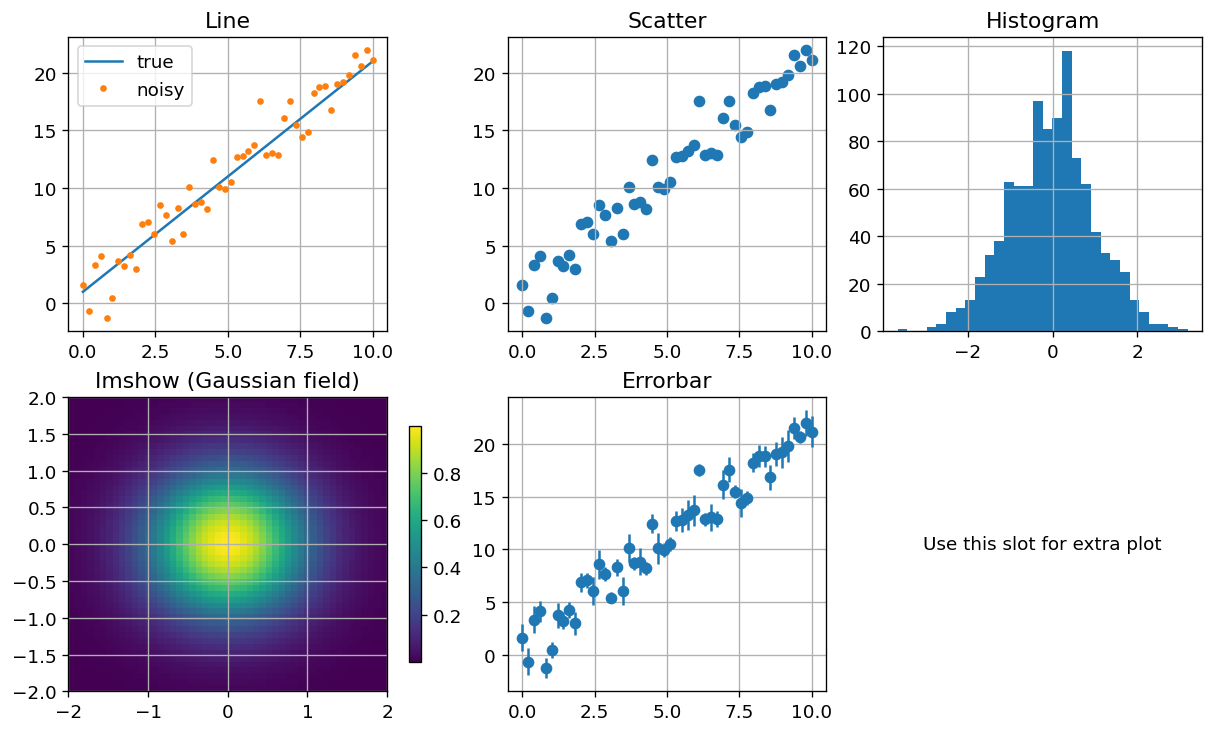

In [19]:
# Data generation
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 50)
y_true = 2.0 * x + 1.0
y_noisy = y_true + rng.normal(0, 2.0, size=x.size)

fig, axs = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)

# Line
axs[0,0].plot(x, y_true, label="true")
axs[0,0].plot(x, y_noisy, ".", label="noisy")
axs[0,0].set_title("Line")
axs[0,0].legend()

# Scatter
axs[0,1].scatter(x, y_noisy)
axs[0,1].set_title("Scatter")

# Histogram
data = rng.normal(loc=0.0, scale=1.0, size=1000)
axs[0,2].hist(data, bins=30)
axs[0,2].set_title("Histogram")

# Imshow (heatmap-like)
grid_x = np.linspace(-2, 2, 50)
grid_y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(grid_x, grid_y)
Z = np.exp(-(X**2 + Y**2))
im = axs[1,0].imshow(Z, extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()],
                     origin="lower", aspect="auto")
axs[1,0].set_title("Imshow (Gaussian field)")
fig.colorbar(im, ax=axs[1,0], shrink=0.8)

# Errorbar
yerr = rng.uniform(0.5, 1.5, size=x.size)
axs[1,1].errorbar(x, y_noisy, yerr=yerr, fmt="o")
axs[1,1].set_title("Errorbar")

# Empty slot for future (e.g., bar or boxplot)
axs[1,2].text(0.5, 0.5, "Use this slot for extra plot", ha="center", va="center")
axs[1,2].set_axis_off()

plt.show()


## התאמות נוספות  
בספריה קיימות פונקציות רבות המאפשרות להציג נתונים בצורה מדעית מדויקת, ברורה או אינטואיטיבית יותר. שימוש נכון בהן הוא מיומנות חשובה בעבודה מדעית. נזכיר בקצרה מספר דוגמאות:

- **סולמות לוגריתמיים**: `ax.set_xscale('log')`, `ax.set_yscale('log')` — מאפשרים להציג נתונים המשתנים באקספוננט או על פני כמה סדרי גודל, כמו ריכוזים במהלך תהליך כימי או ספקטרום מדוד. שימוש נכון בסולם לוגריתמי יכול להפוך עקומה לא ליניארית לקו ישר, ולחשוף קשרים חבויים.
- **טיקים ותוויות**: מאפשרים שליטה מלאה באופן הצגת המספרים בצירים (מדעי, אקספוננציאלי או רגיל), וכן הוספת **יחידות פיזיקליות** לכותרות הצירים. התאמות אלו מבטיחות שהגרף יהיה קריא.
- **מקרא ו־annotations**: הוספת מקרא (legend) חיונית כשיש כמה עקומות באותו גרף. בעזרת `ax.annotate` ניתן גם להדגיש נקודות מיוחדות בנתונים, ולהסביר אותן באמצעות חצים וטקסט.
- **ציר תאום**: `()ax.twinx` או `()ax.twiny` מאפשרים לייצר גרף עם שני צירים בלתי־תלויים, למשל צירים עם יחידות שונות.
- **Colormaps**: שימוש במפות צבעים מדעיות (כמו `viridis` או `inferno`) מאפשר קידוד של פרמטר נוסף באמצעות צבע. זה חשוב במיוחד להצגת סדרות של ניסויים או סימולציות, תוך שמירה על נגישות גם לעיוורי צבעים. 

```{note} 
ביחד, התאמות אלו מאפשרות לא רק ליצור גרף יפה יותר, אלא להעביר מסר מדעי ברור ומדויק, ולחסוך לקורא את הצורך בניחושים או חישובים נוספים.  
```